# NN - Домашнее задание 2

**ФИО:** Захаров Роман, Пелехов Ярослав.  
**Kaggle ники / команда:** Zakharov Roman, Yaroslav Pelekhov.  
**Итоговая позиция на финальном leaderboard:** 9 место.  
**Финальный leaderboard score:** 0.64184.

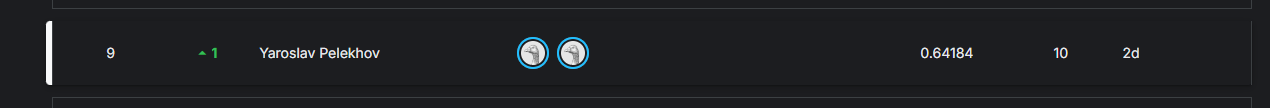


## Структура проекта

Основные файлы:

- `train.parquet`, `test.parquet` - данные соревнования;
- `sample_submission.csv` - шаблон отправки;
- `submission.csv` - текущий финальный файл для Kaggle;
- `artifacts_*` - сохранённые признаки, OOF-предсказания, test-предсказания и логи;
- `train_*.py` - воспроизводимые скрипты отдельных этапов.

Ноутбук ниже показывает итоговый пайплайн, результаты и команды для повторного запуска. Тяжёлые этапы вынесены в `.py`-скрипты, чтобы notebook оставался читаемым.

In [ ]:
from pathlib import Path
import json

import pandas as pd
import numpy as np

ROOT = Path(".")

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

clip_summary = read_json(ROOT / "artifacts_clip" / "summary.json")
conv_summary = read_json(ROOT / "artifacts_convnext" / "summary.json")
mlp_summary = read_json(ROOT / "artifacts_mlp" / "summary.json")
b16_summary = read_json(ROOT / "artifacts_clip_b16" / "summary.json")
b16_cat_summary = read_json(ROOT / "artifacts_clip_b16" / "summary_catboost.json")

y_true = pd.read_parquet(ROOT / "train.parquet", columns=["is_image1_better"])["is_image1_better"].to_numpy()

def auc_from_oof(path):
    from sklearn.metrics import roc_auc_score
    return float(roc_auc_score(y_true, np.load(path)))

clip_catboost_auc = clip_summary.get("catboost_auc")
if clip_catboost_auc is None:
    clip_catboost_auc = auc_from_oof(ROOT / "artifacts_clip" / "oof_catboost.npy")

print("summaries loaded")


summaries loaded


## Данные

В train каждая строка содержит две картинки и бинарный таргет. В test таргета нет, для него строится `submission.csv`.


In [ ]:
train_y = pd.read_parquet(ROOT / "train.parquet", columns=["is_image1_better"])
sample_submission = pd.read_csv(ROOT / "sample_submission.csv")

data_overview = pd.DataFrame(
    {
        "split": ["train", "test", "sample_submission"],
        "rows": [len(train_y), len(sample_submission), len(sample_submission)],
        "columns": ["image_1, image_2, is_image1_better", "image_1, image_2", "index, is_image1_better"],
    }
)

print("positive rate:", round(float(train_y["is_image1_better"].mean()), 4))
data_overview


positive rate: 0.347


,split,rows,columns
0,train,8710,"image_1, image_2, is_image1_better"
1,test,4290,"image_1, image_2"
2,sample_submission,4290,"index, is_image1_better"


## Краткое intro

Цель решения - научиться сравнивать две картинки между собой, а не просто классифицировать одну картинку отдельно. Поэтому все признаки строятся pairwise: для первой и второй картинки считаются embeddings, после чего добавляются разности, модули разностей и произведения.

Основная проверка качества проводится через out-of-fold ROC AUC. Это снижает риск подобрать веса ансамбля только под один случайный split.


## Идея решения

Решение построено как ансамбль моделей поверх признаков изображений.

1. Для каждой картинки считаются embeddings с помощью pretrained image encoders.
2. Для пары строятся признаки: embedding первой картинки, embedding второй картинки, разность, модуль разности, произведение и простые статистики изображения.
3. На этих признаках обучаются LightGBM, CatBoost и небольшой PyTorch MLP.
4. Для устойчивости используется swap-аугментация: при перестановке картинок таргет меняется на противоположный.
5. Финальное предсказание получается как rank-ансамбль нескольких OOF-проверенных моделей.


## Использованные модели

**CLIP ViT-B/32.** Основной encoder для визуальных признаков. Поверх его embeddings обучены LightGBM и CatBoost.

**ConvNeXt Tiny.** Дополнительный encoder с ImageNet-pretrained весами. Отдельно он слабее CLIP, но добавляет немного разнообразия в ансамбль.

**PyTorch MLP-head.** Небольшая полносвязная модель поверх объединённых CLIP и ConvNeXt признаков. Обучается по `BCEWithLogitsLoss`, качество контролируется по ROC AUC, используется early stopping.

**CLIP ViT-B/16.** Второй CLIP encoder с меньшим patch size. Он лучше учитывает мелкие детали и локальные дефекты генерации. Поверх B/16 признаков обучены LightGBM и CatBoost.


## Самописная PyTorch-архитектура

Для выполнения требования по PyTorch была обучена собственная MLP-архитектура поверх заранее извлечённых визуальных признаков. Модель получает признаки обеих картинок, их разность, модуль разности и произведение. Это не готовая классификационная голова из библиотеки, а явно заданная полносвязная сеть.


In [ ]:
import torch
from torch import nn


class PairMLP(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 2048),
            nn.BatchNorm1d(2048),
            nn.SiLU(),
            nn.Dropout(0.35),
            nn.Linear(2048, 768),
            nn.BatchNorm1d(768),
            nn.SiLU(),
            nn.Dropout(0.25),
            nn.Linear(768, 192),
            nn.SiLU(),
            nn.Dropout(0.15),
            nn.Linear(192, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


in_features = 6460
model = PairMLP(in_features)
params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Количество параметров: {params:,}")


PairMLP(
  (net): Sequential(
    (0): Linear(in_features=6460, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=2048, out_features=768, bias=True)
    (5): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=768, out_features=192, bias=True)
    (9): SiLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): Linear(in_features=192, out_features=1, bias=True)
  )
)
Количество параметров: 14,959,233


In [ ]:
mlp_folds = pd.read_csv(ROOT / "artifacts_mlp" / "mlp_folds.csv")
mlp_folds[["fold", "best_auc", "best_epoch", "time_sec"]]


,fold,best_auc,best_epoch,time_sec
0,1,0.651587,2,17.116990
1,2,0.646274,2,16.971472
2,3,0.639110,4,18.169431
3,4,0.654897,3,18.001111
4,5,0.656848,2,17.067549


In [ ]:
rows = [
    {"stage": "CLIP B/32 + LightGBM", "oof_roc_auc": clip_summary["lgbm_auc"]},
    {"stage": "CLIP B/32 + CatBoost", "oof_roc_auc": clip_catboost_auc},
    {"stage": "CLIP B/32 ensemble", "oof_roc_auc": clip_summary["best_oof_auc"]},
    {"stage": "ConvNeXt LightGBM", "oof_roc_auc": conv_summary["convnext_lgbm_auc"]},
    {"stage": "Ensemble with ConvNeXt", "oof_roc_auc": conv_summary["final_oof_auc"]},
    {"stage": "PyTorch MLP-head", "oof_roc_auc": mlp_summary["mlp_auc"]},
    {"stage": "Ensemble with MLP", "oof_roc_auc": mlp_summary["best_ensemble_auc"]},
    {"stage": "CLIP B/16 + LightGBM", "oof_roc_auc": b16_summary["b16_lgbm_auc"]},
    {"stage": "Ensemble with B/16", "oof_roc_auc": b16_summary["best_ensemble_auc"]},
    {"stage": "CLIP B/16 + CatBoost", "oof_roc_auc": b16_cat_summary["b16_catboost_auc"]},
    {"stage": "Final ensemble", "oof_roc_auc": b16_cat_summary["best_ensemble_auc"]},
]

results = pd.DataFrame(rows)
results["oof_roc_auc"] = results["oof_roc_auc"].map(lambda x: round(float(x), 5))
results


,stage,oof_roc_auc
0,CLIP B/32 + LightGBM,0.64643
1,CLIP B/32 + CatBoost,0.63676
2,CLIP B/32 ensemble,0.64643
3,ConvNeXt LightGBM,0.62250
4,Ensemble with ConvNeXt,0.65298
5,PyTorch MLP-head,0.64735
6,Ensemble with MLP,0.66019
7,CLIP B/16 + LightGBM,0.64056
8,Ensemble with B/16,0.66270
9,CLIP B/16 + CatBoost,0.62698


## Финальный ансамбль

В финальной версии используется rank-ансамбль. Для ROC AUC это удобно, потому что метрика зависит от порядка объектов, а не от абсолютной калибровки вероятностей.


In [ ]:
weights = pd.Series(b16_cat_summary["best_weights"], name="weight").to_frame()
weights["weight"] = weights["weight"].map(lambda x: round(float(x), 4))
weights


,weight
clip_lgbm,0.2259
clip_catboost,0.1710
convnext_lgbm,0.0009
mlp,0.3578
clip_b16_lgbm,0.1885
clip_b16_catboost,0.0559


## Проверка submission

Файл должен иметь тот же размер и те же колонки, что и `sample_submission.csv`. Значения в `is_image1_better` являются score для ROC AUC.


In [ ]:
submission = pd.read_csv(ROOT / "submission.csv")

print("shape:", submission.shape)
print("columns:", list(submission.columns))
print("has nulls:", bool(submission.isna().any().any()))
submission["is_image1_better"].describe()


shape: (4290, 2)
columns: ['index', 'is_image1_better']
has nulls: False


count    4290.000000
mean        0.500000
std         0.264407
min         0.000451
25%         0.284504
50%         0.500665
75%         0.721294
max         0.999265
Name: is_image1_better, dtype: float64

## Воспроизведение

Полный запуск занимает заметное время, поэтому команды ниже оставлены закомментированными. Запускать их нужно по порядку.


In [ ]:
# 1. CLIP ViT-B/32 + LightGBM
# %run train_clip_auc.py

# 2. CatBoost на CLIP B/32 признаках
# %run train_catboost_clip_auc.py

# 3. ConvNeXt признаки + LightGBM + ансамбль
# %run train_convnext_auc.py

# 4. PyTorch MLP-head поверх CLIP+ConvNeXt признаков
# %run train_mlp_features_auc.py

# 5. CLIP ViT-B/16 + LightGBM + ансамбль
# %run train_clip_b16_auc.py

# 6. CatBoost на CLIP B/16 признаках + финальный ансамбль
# %run train_catboost_b16_auc.py


In [ ]:
scripts = [
    "train_clip_auc.py",
    "train_catboost_clip_auc.py",
    "train_convnext_auc.py",
    "train_mlp_features_auc.py",
    "train_clip_b16_auc.py",
    "train_catboost_b16_auc.py",
]

pd.DataFrame(
    {
        "script": scripts,
        "exists": [(ROOT / s).exists() for s in scripts],
        "size_kb": [round((ROOT / s).stat().st_size / 1024, 1) for s in scripts],
    }
)


,script,exists,size_kb
0,train_clip_auc.py,True,18.2
1,train_catboost_clip_auc.py,True,6.8
2,train_convnext_auc.py,True,11.2
3,train_mlp_features_auc.py,True,12.3
4,train_clip_b16_auc.py,True,17.7
5,train_catboost_b16_auc.py,True,10.9


## Анализ экспериментов

Что было проверено:

- простая модель, обучаемая с нуля;
- CLIP ViT-B/32 как основной открытый pretrained encoder;
- LightGBM и CatBoost поверх pairwise-признаков;
- ConvNeXt Tiny как дополнительный открытый pretrained encoder;
- самописная PyTorch MLP-голова поверх объединённых признаков;
- CLIP ViT-B/16 как второй encoder с более мелким patch size;
- rank-ансамбли по out-of-fold предсказаниям.

Что пошло не так или могло ухудшить результат:

- модель с нуля не успевала выучить хорошие визуальные признаки на таком размере данных;
- отдельные дополнительные модели, например ConvNeXt и CatBoost B/16, были слабее основных моделей;
- простое увеличение числа эпох MLP без контроля validation AUC могло привести к переобучению;
- абсолютные вероятности разных моделей были откалиброваны по-разному, поэтому простое усреднение вероятностей было менее надёжным.

Почему итоговый подход сработал лучше:

- pretrained encoders уже содержат сильные визуальные признаки;
- swap-аугментация явно учитывает симметрию задачи сравнения двух картинок;
- OOF-валидация позволяет подбирать веса ансамбля без прямой подгонки под test;
- rank-ансамбль хорошо согласуется с ROC AUC, потому что метрика зависит от порядка объектов;
- слабые, но разные модели могут улучшать ансамбль за счёт несовпадающих ошибок.


## Где такое решение можно использовать

Подход подходит для задач, где нужно сравнивать два визуальных объекта:

- выбор лучшего варианта генерации;
- фильтрация неудачных изображений;
- ранжирование визуального контента перед показом пользователю;
- контроль качества креативов, карточек товаров или рекламных изображений;
- сравнение вариантов дизайна по визуальному качеству.

Практический плюс решения в том, что самая дорогая часть вынесена в кеширование embeddings. После этого можно быстро проверять разные модели и ансамбли.


##Итог
Лучший результат дало не простое увеличение числа эпох, а комбинация pretrained encoders, самописной PyTorch MLP-головы, swap-аугментации и rank-ансамбля. Дальнейшее улучшение, скорее всего, потребовало бы более тяжёлого encoder-а, например CLIP ViT-L/14, EVA-CLIP или DINOv2.